In [20]:
import os
os.environ['PATH'] += os.pathsep + '/Library/TeX/texbin'
import shutil
shutil.which("pdflatex")

'/Library/TeX/texbin/pdflatex'

In [21]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from morl_behavior_objective.analysis.metrics_clean import compute_zadu_metrics
from morl_behavior_objective.analysis.utils_analysis import compute_lipschitz_constants
from morl_behavior_objective.utils import load_ground_truth_data
from morl_behavior_objective.utils import load_transformer_embeddings

# Set matplotlib parameters
mpl.rcParams["pdf.fonttype"] = 42  # use true-type
mpl.rcParams["ps.fonttype"] = 42  # use true-type
mpl.rcParams["font.size"] = 18
mpl.rcParams["lines.linewidth"] = 2.2
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath,amssymb,underscore}"
mpl.rcParams["text.usetex"] = True
mpl.rcParams["xtick.labelsize"] = 18
mpl.rcParams["ytick.labelsize"] = 18
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["axes.labelsize"] = 18
mpl.rcParams["legend.fontsize"] = 16

colors = [
    "#5CB5FF",
    "#D55E00",
    "#009E73",
    "#e6194b",
]

## Load all the data

### Ground Truth and Returns embeddings

In [22]:
seed = 0
# Configuration for datasets
datasets = {
    "left_right": {
        "name": "left_right_dst",
        "num_files": 6,
        "embedding_path": f"../../trajectories/left_right_dst/final_embeddings/mean_be_DSTLR_e100_seed{seed}.json",
        "baselie_path": f"../../trajectories/left_right_dst/final_embeddings/mean_basic_DSTLR_e100_seed{seed}.json"
    },
    "smooth": {
        "name": "smooth",
        "num_files": 10,
        "embedding_path": f"../../trajectories/smooth/final_embeddings/mean_be_DSTS_e100_seed{seed}.json",
        "baseline_path": f"../../trajectories/smooth/final_embeddings/mean_basic_DSTS_e100_seed{seed}.json"
    },
    "louvre": {
        "name": "louvre_dst",
        "num_files": 6,
        "embedding_path": f"../../trajectories/louvre_dst/embeddings/mean_be_DSTL_e100_seed{seed}.json"
    }
}

# Load ground truth data
all_gt_emb, all_returns_lr = load_ground_truth_data(
    datasets["left_right"]["name"],
    datasets["left_right"]["num_files"]
)

all_gt_emb_smooth, all_returns_smooth = load_ground_truth_data(
    datasets["smooth"]["name"],
    datasets["smooth"]["num_files"]
)

all_gt_emb_louvre, all_returns_louvre = load_ground_truth_data(
    datasets["louvre"]["name"],
    datasets["louvre"]["num_files"]
)

# Load transformer embeddings
all_t_emb_lr, _ = load_transformer_embeddings(datasets["left_right"]["embedding_path"])
all_t_emb_lr_baseline, _ = load_transformer_embeddings(datasets["left_right"]["baselie_path"])
all_t_emb_smooth, _ = load_transformer_embeddings(datasets["smooth"]["embedding_path"])
all_t_emb_smooth_baseline, _ = load_transformer_embeddings(datasets["smooth"]["baseline_path"])
all_t_emb_louvre, _ = load_transformer_embeddings(datasets["louvre"]["embedding_path"])

# Print summary
print("Ground truth data loaded successfully:")
print(f" Ground truth embeddings Left right:  all_gt_emb shape: {all_gt_emb.shape}")
print(f" Ground truth returns Left right:  all_returns_lr shape: {all_returns_lr.shape}")
print(f" Ground truth embeddings Smooth:  all_gt_emb_smooth shape: {all_gt_emb_smooth.shape}")

print(f" Ground truth returns Smooth:  all_returns_smooth shape: {all_returns_smooth.shape}")
print(f" Ground truth embeddings Louvre:  all_gt_emb_louvre shape: {all_gt_emb_louvre.shape}")
print(f" Ground truth returns Louvre:  all_returns_louvre shape: {all_returns_louvre.shape}")
print("\nTransformer embeddings loaded successfully:")
print(f" Transformer embeddings Left right 3D:  all_t_emb_3D shape: {all_t_emb_lr.shape}")
print(f" Transformer embeddings Smooth new:  all_t_emb_smooth_new shape: {all_t_emb_smooth.shape}")
print(f" Transformer embeddings Louvre:  all_t_emb_louvre shape: {all_t_emb_louvre.shape}")
print("\nBaseline embeddings loaded successfully:")
print(f" Baseline embeddings Left right 3D:  all_t_emb_lr_baseline shape: {all_t_emb_lr_baseline.shape}")
print(f" Baseline embeddings Smooth new:  all_t_emb_smooth_baseline shape: {all_t_emb_smooth_baseline.shape}")



Ground truth data loaded successfully:
 Ground truth embeddings Left right:  all_gt_emb shape: (6, 2)
 Ground truth returns Left right:  all_returns_lr shape: (6, 2)
 Ground truth embeddings Smooth:  all_gt_emb_smooth shape: (10, 2)
 Ground truth returns Smooth:  all_returns_smooth shape: (10, 2)
 Ground truth embeddings Louvre:  all_gt_emb_louvre shape: (6, 2)
 Ground truth returns Louvre:  all_returns_louvre shape: (6, 2)

Transformer embeddings loaded successfully:
 Transformer embeddings Left right 3D:  all_t_emb_3D shape: (6, 3)
 Transformer embeddings Smooth new:  all_t_emb_smooth_new shape: (10, 3)
 Transformer embeddings Louvre:  all_t_emb_louvre shape: (6, 3)

Baseline embeddings loaded successfully:
 Baseline embeddings Left right 3D:  all_t_emb_lr_baseline shape: (6, 3)
 Baseline embeddings Smooth new:  all_t_emb_smooth_baseline shape: (10, 3)


## Trustworthiness and Continuity

In [8]:
# Makes a histogram of the Lipschitz constants of the GTE embeddings vs the returns

lipschitz_constants_lr_gt, d_objs_lr_gt, d_embs_lr_gt, sorted_pf_lr_gt, sorted_emb_lr_gt = compute_lipschitz_constants(pareto_frontier=all_returns_lr, embeddings=all_gt_emb)
lipschitz_constants_lr_t, d_objs_lr_t, d_embs_lr_t, sorted_pf_lr_t, sorted_emb_lr_t = compute_lipschitz_constants(pareto_frontier=all_returns_lr, embeddings=all_t_emb_lr)
lipschitz_constants_lr_t_baseline, d_objs_lr_t_baseline, d_embs_lr_t_baseline, sorted_pf_lr_t_baseline, sorted_emb_lr_t_baseline = compute_lipschitz_constants(pareto_frontier=all_returns_lr, embeddings=all_t_emb_lr_baseline)

lipschitz_constants_smooth_gt, d_objs_smooth_gt, d_embs_smooth_gt, sorted_pf_smooth_gt, sorted_emb_smooth_gt = compute_lipschitz_constants(pareto_frontier=all_returns_smooth, embeddings=all_gt_emb_smooth)
lipschitz_constants_smooth_t, d_objs_smooth_t, d_embs_smooth_t, sorted_pf_smooth_t, sorted_emb_smooth_t = compute_lipschitz_constants(pareto_frontier=all_returns_smooth, embeddings=all_t_emb_smooth)
lipschitz_constants_smooth_t_baseline, d_objs_smooth_t_baseline, d_embs_smooth_t_baseline, sorted_pf_smooth_t_baseline, sorted_emb_smooth_t_baseline = compute_lipschitz_constants(pareto_frontier=all_returns_smooth, embeddings=all_t_emb_smooth_baseline)

lipschitz_constants_louvre_gt, d_objs_louvre_gt, d_embs_louvre_gt, sorted_pf_louvre_gt, sorted_emb_louvre_gt = compute_lipschitz_constants(pareto_frontier=all_returns_louvre, embeddings=all_gt_emb_louvre)
lipschitz_constants_louvre_t, d_objs_louvre_t, d_embs_louvre_t, sorted_pf_louvre_t, sorted_emb_louvre_t = compute_lipschitz_constants(pareto_frontier=all_returns_louvre, embeddings=all_t_emb_louvre)

print("Left-Right front", all_returns_lr)
print(f"Lipschitz constants Left-Right: {lipschitz_constants_lr_gt}")
print(f"Lipschitz constants Ground Truth Smooth: {lipschitz_constants_smooth_gt}")
print(f"Lipschitz constants Transformer Left-Right: {lipschitz_constants_lr_t}")
print(f"Lipschitz constants Transformer Smooth: {lipschitz_constants_smooth_t}")
print(f"Lipschitz constants Ground Truth Louvre: {lipschitz_constants_louvre_gt}")
print(f"Lipschitz constants Transformer Louvre: {lipschitz_constants_louvre_t}")

Computing Lipschitz constant between policy 0 and 1
4.123105625617661
18.027756377319946
Lipshitz: 4.372373160976031
Lipschitz constant for policy 0 ([124. -19.], [ 9 10]) to 1 ([120. -18.], [-9  9]): 4.372373160976031, d_obj: 4.123105625617661, d_emb: 18.027756377319946
Computing Lipschitz constant between policy 1 and 2
95.08417323613851
2.8284271247461903
Lipshitz: 0.02974656063656232
Lipschitz constant for policy 1 ([120. -18.], [-9  9]) to 2 ([ 25. -14.], [-7  7]): 0.02974656063656232, d_obj: 95.08417323613851, d_emb: 2.8284271247461903
Computing Lipschitz constant between policy 2 and 3
1.4142135623730951
13.0
Lipshitz: 9.192388155425117
Lipschitz constant for policy 2 ([ 25. -14.], [-7  7]) to 3 ([ 24. -13.], [6 7]): 9.192388155425117, d_obj: 1.4142135623730951, d_emb: 13.0
Computing Lipschitz constant between policy 3 and 4
17.72004514666935
10.44030650891055
Lipshitz: 0.5891805817928689
Lipschitz constant for policy 3 ([ 24. -13.], [6 7]) to 4 ([ 7. -8.], [-4  4]): 0.589180581

In [5]:

print("=== ZADU METRICS COMPUTATION ===")

# 1. Raw metrics
print("\n--- Left right ---")

print("Left-right: Returns vs GTE:", compute_zadu_metrics(all_returns_lr, all_gt_emb))
print("Left-right: Returns vs TE 3D:", compute_zadu_metrics(all_returns_lr, all_t_emb_lr))
print("Left-right: GTE vs TE 3D:", compute_zadu_metrics(all_gt_emb, all_t_emb_lr))


print("\n--- Smooth ---")
print("Smooth: Returns vs TE:", compute_zadu_metrics(all_returns_smooth, all_t_emb_smooth))
print("Smooth: Returns vs GTE:", compute_zadu_metrics(all_returns_smooth, all_gt_emb_smooth))
print("Smooth: GTE vs TE:", compute_zadu_metrics(all_gt_emb_smooth, all_t_emb_smooth))

=== ZADU METRICS COMPUTATION ===

--- Left right ---
Left-right: Returns vs GTE: [{'trustworthiness': 0.5666666666666665, 'continuity': 0.5}, {'mrre_false': 0.5897435897435898, 'mrre_missing': 0.5}]
Left-right: Returns vs TE 3D: [{'trustworthiness': 0.5666666666666665, 'continuity': 0.5333333333333333}, {'mrre_false': 0.5897435897435898, 'mrre_missing': 0.5256410256410257}]
Left-right: GTE vs TE 3D: [{'trustworthiness': 1.0, 'continuity': 1.0}, {'mrre_false': 0.923076923076923, 'mrre_missing': 0.923076923076923}]

--- Smooth ---
Smooth: Returns vs TE: [{'trustworthiness': 1.0, 'continuity': 1.0}, {'mrre_false': 0.9640000000000001, 'mrre_missing': 0.9640000000000001}]
Smooth: Returns vs GTE: [{'trustworthiness': 1.0, 'continuity': 1.0}, {'mrre_false': 1.0, 'mrre_missing': 1.0}]
Smooth: GTE vs TE: [{'trustworthiness': 1.0, 'continuity': 1.0}, {'mrre_false': 0.9640000000000001, 'mrre_missing': 0.9640000000000001}]


## Scatter plots

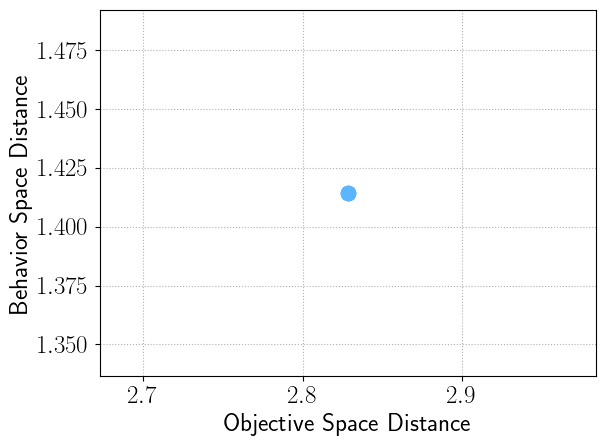

In [33]:
plt.scatter(d_objs_smooth_gt, d_embs_smooth_gt, c=colors[0], marker="o", s=100)
plt.xlabel("Objective Space Distance")
plt.ylabel("Behavior Space Distance")
#plt.title("Smooth Ground Truth")


plt.grid(True, linestyle=":")
plt.tight_layout()

plt.savefig("scatterplots/smooth_ground_truth.pdf")
plt.show()

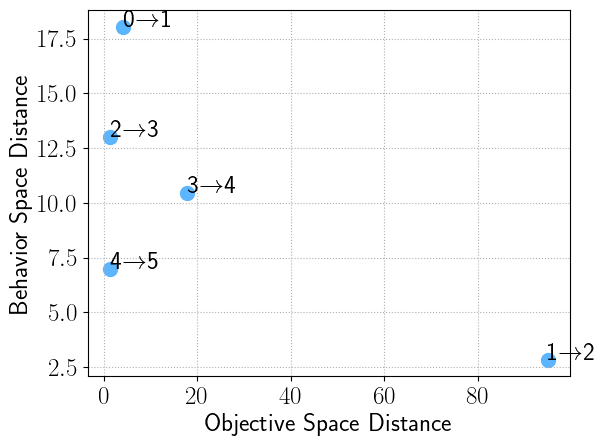

In [32]:
# Plot ground truth scatter plots
plt.scatter(d_objs_lr_gt, d_embs_lr_gt, c=colors[0], marker="o", s=100)
plt.xlabel("Objective Space Distance")
plt.ylabel("Behavior Space Distance")
#plt.title("Left-Right Ground Truth")
# add index as text labels
for i, txt in enumerate(range(len(d_objs_lr_gt))):
    plt.annotate(f"{i}" + r"$\rightarrow$" + f"{i+1}", (d_objs_lr_gt[i], d_embs_lr_gt[i]))


plt.grid(True, linestyle=":")
plt.tight_layout()

plt.savefig("scatterplots/left_right_ground_truth.pdf")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'scatterplots/louvre_ground_truth.pdf'

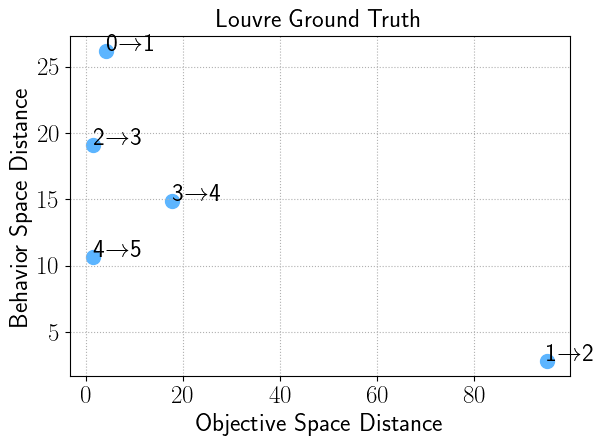

In [6]:
# Plot ground truth scatter plots
plt.scatter(d_objs_louvre_gt, d_embs_louvre_gt, c=colors[0], marker="o", s=100)
plt.xlabel("Objective Space Distance")
plt.ylabel("Behavior Space Distance")
plt.title("Louvre Ground Truth")
# add index as text labels
for i, txt in enumerate(range(len(d_objs_louvre_gt))):
    plt.annotate(f"{i}" + r"$\rightarrow$" + f"{i+1}", (d_objs_louvre_gt[i], d_embs_louvre_gt[i]))


plt.grid(True, linestyle=":")
plt.tight_layout()

plt.savefig("scatterplots/louvre_ground_truth.pdf")
plt.show()

In [36]:
def plot_scatter_distances(d_objs_lr_t, d_embs_lr_t, instance, mean=False):

    print("Distance between points in objective space and embedding space")
    for i in range(len(d_objs_lr_t)):
        print(f"Distance {i} and {i+1} in objective space: {d_objs_lr_t[i]}")
        print(f"Distance {i} and {i+1} in embedding space: {d_embs_lr_t[i]}")

    plt.scatter(d_objs_lr_t, d_embs_lr_t, c=colors[0], marker="o", s=100)
    plt.xlabel("Objective Space Distance")
    plt.ylabel("Behavior Space Distance")
    #plt.title(f"{instance} Transformer")
    # add index as text labels
    for i, txt in enumerate(range(len(d_objs_lr_t))):
        plt.annotate(f"{i}" + r"$\rightarrow$" + f"{i+1}", (d_objs_lr_t[i], d_embs_lr_t[i]))

    plt.grid(True, linestyle=":")
    plt.tight_layout()


import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ======================
# CONFIG
# ======================
N_SEEDS = 5
os.makedirs("scatterplots", exist_ok=True)

datasets = {
    "left_right": {
        "pretty_name": "Left-Right",
        "pf_name": "left_right_dst",
        "num_files": 6,
        "embedding_path": "../../trajectories/left_right_dst/final_embeddings/mean_be_DSTLR_e100_seed{seed}.json",
        "baseline_path": "../../trajectories/left_right_dst/final_embeddings/mean_basic_DSTLR_e100_seed{seed}.json",
    },
    "smooth": {
        "pretty_name": "Smooth",
        "pf_name": "smooth",
        "num_files": 10,
        "embedding_path": "../../trajectories/smooth/final_embeddings/mean_be_DSTS_e100_seed{seed}.json",
        "baseline_path": "../../trajectories/smooth/final_embeddings/mean_basic_DSTS_e100_seed{seed}.json",
    },
}

# ======================
# STORAGE FOR MEAN SCATTERS
# ======================
mean_scatter_data = defaultdict(lambda: {
    "d_objs": [],
    "d_embs": [],
})

# ======================
# MAIN LOOP
# ======================
for seed in range(N_SEEDS):
    print(f"\n--- Seed {seed} ---")

    for ds_key, ds in datasets.items():
        print(f"[{ds_key}] loading data")

        # Pareto frontier (objective space)
        _, returns = load_ground_truth_data(
            ds["pf_name"],
            ds["num_files"],
        )

        # Transformer embeddings
        t_emb, _ = load_transformer_embeddings(
            ds["embedding_path"].format(seed=seed)
        )

        # Baseline embeddings
        t_emb_base, _ = load_transformer_embeddings(
            ds["baseline_path"].format(seed=seed)
        )

        # ======================
        # Transformer
        # ======================
        (
            lipschitz_t,
            d_objs_t,
            d_embs_t,
            sorted_pf_t,
            sorted_emb_t,
        ) = compute_lipschitz_constants(
            pareto_frontier=returns,
            embeddings=t_emb,
        )

        plot_scatter_distances(
            d_objs_t,
            d_embs_t,
            f"{ds['pretty_name']} Transformer",
        )
        plt.savefig(
            f"scatterplots/{ds_key}_transformer_seed{seed}.pdf"
        )
        plt.close()

        mean_scatter_data[f"{ds_key}_transformer"]["d_objs"].append(d_objs_t)
        mean_scatter_data[f"{ds_key}_transformer"]["d_embs"].append(d_embs_t)

        # ======================
        # Baseline
        # ======================
        (
            lipschitz_t_base,
            d_objs_t_base,
            d_embs_t_base,
            sorted_pf_t_base,
            sorted_emb_t_base,
        ) = compute_lipschitz_constants(
            pareto_frontier=returns,
            embeddings=t_emb_base,
        )

        plot_scatter_distances(
            d_objs_t_base,
            d_embs_t_base,
            f"{ds['pretty_name']} Baseline",
        )
        plt.savefig(
            f"scatterplots/{ds_key}_baseline_seed{seed}.pdf"
        )
        plt.close()

        mean_scatter_data[f"{ds_key}_baseline"]["d_objs"].append(d_objs_t_base)
        mean_scatter_data[f"{ds_key}_baseline"]["d_embs"].append(d_embs_t_base)

print("\nPer-seed scatter plots completed ✔")

# ======================
# MEAN SCATTER PLOTS
# ======================
print("\n=== MEAN SCATTER PLOTS ACROSS SEEDS ===")

for key, data in mean_scatter_data.items():
    d_objs_all = np.array(data["d_objs"])
    d_embs_all = np.array(data["d_embs"])

    # Sanity checks
    assert d_objs_all.shape[0] == N_SEEDS
    assert d_objs_all.shape == d_embs_all.shape

    # Mean across seeds
    d_objs_mean = d_objs_all.mean(axis=0)
    d_embs_mean = d_embs_all.mean(axis=0)

    # Title formatting
    ds_key_name, method = key.split("_", 1)
    title = f"{ds_key_name.replace('_', ' ').title()} {method.title()} (Mean)"

    plot_scatter_distances(
        d_objs_mean,
        d_embs_mean,
        title, mean=True
    )
    plt.savefig(f"scatterplots/{key}_mean.pdf")
    plt.close()

print("Mean scatter plots generated ✔")



--- Seed 0 ---
[left_right] loading data
Computing Lipschitz constant between policy 0 and 1
4.123105625617661
1.9387871256930438
Lipshitz: 0.4702249473423578
Lipschitz constant for policy 0 ([124. -19.], [-0.78017813  0.29525468  0.55149466]) to 1 ([120. -18.], [ 0.76459116 -0.61828047 -0.18201533]): 0.4702249473423578, d_obj: 4.123105625617661, d_emb: 1.9387871256930438
Computing Lipschitz constant between policy 1 and 2
95.08417323613851
0.45539672768818995
Lipshitz: 0.004789406188106897
Lipschitz constant for policy 1 ([120. -18.], [ 0.76459116 -0.61828047 -0.18201533]) to 2 ([ 25. -14.], [ 0.57515895 -0.79507482  0.19247817]): 0.004789406188106897, d_obj: 95.08417323613851, d_emb: 0.45539672768818995
Computing Lipschitz constant between policy 2 and 3
1.4142135623730951
1.5957812455664804
Lipshitz: 1.1283877400303735
Lipschitz constant for policy 2 ([ 25. -14.], [ 0.57515895 -0.79507482  0.19247817]) to 3 ([ 24. -13.], [-0.68856263  0.02106456  0.72487092]): 1.1283877400303735, d

In [ ]:
import os
import matplotlib.pyplot as plt
from collections import defaultdict

N_SEEDS = 5
os.makedirs("scatterplots", exist_ok=True)

datasets = {
    "left_right": {
        "name": "Left-Right",
        "has_baseline": True,
    },
    "smooth": {
        "name": "Smooth",
        "has_baseline": True,
    },
}

for seed in range(N_SEEDS):
    print(f"\n--- Seed {seed} ---")

    # ======================
    # Load per-seed data
    # ======================
    all_returns_lr, all_gt_emb_lr, all_t_emb_lr, all_t_emb_lr_baseline = \
        load_left_right_data(seed)

    all_returns_smooth, all_gt_emb_smooth, all_t_emb_smooth, all_t_emb_smooth_baseline = \
        load_smooth_data(seed)

    # ======================
    # LEFT–RIGHT
    # ======================
    print("[left_right] computing Lipschitz constants")

    (
        lipschitz_lr_gt,
        d_objs_lr_gt,
        d_embs_lr_gt,
        sorted_pf_lr_gt,
        sorted_emb_lr_gt,
    ) = compute_lipschitz_constants(
        pareto_frontier=all_returns_lr,
        embeddings=all_gt_emb_lr,
    )

    (
        lipschitz_lr_t,
        d_objs_lr_t,
        d_embs_lr_t,
        sorted_pf_lr_t,
        sorted_emb_lr_t,
    ) = compute_lipschitz_constants(
        pareto_frontier=all_returns_lr,
        embeddings=all_t_emb_lr,
    )

    (
        lipschitz_lr_t_base,
        d_objs_lr_t_base,
        d_embs_lr_t_base,
        sorted_pf_lr_t_base,
        sorted_emb_lr_t_base,
    ) = compute_lipschitz_constants(
        pareto_frontier=all_returns_lr,
        embeddings=all_t_emb_lr_baseline,
    )

    # --- plots ---
    plot_scatter_distances(d_objs_lr_t, d_embs_lr_t, "Left-Right Transformer")
    plt.savefig(f"scatterplots/left_right_transformer_seed{seed}.pdf")
    plt.close()

    plot_scatter_distances(
        d_objs_lr_t_base, d_embs_lr_t_base, "Left-Right Baseline"
    )
    plt.savefig(f"scatterplots/left_right_baseline_seed{seed}.pdf")
    plt.close()

    # ======================
    # SMOOTH
    # ======================
    print("[smooth] computing Lipschitz constants")

    (
        lipschitz_smooth_gt,
        d_objs_smooth_gt,
        d_embs_smooth_gt,
        sorted_pf_smooth_gt,
        sorted_emb_smooth_gt,
    ) = compute_lipschitz_constants(
        pareto_frontier=all_returns_smooth,
        embeddings=all_gt_emb_smooth,
    )

    (
        lipschitz_smooth_t,
        d_objs_smooth_t,
        d_embs_smooth_t,
        sorted_pf_smooth_t,
        sorted_emb_smooth_t,
    ) = compute_lipschitz_constants(
        pareto_frontier=all_returns_smooth,
        embeddings=all_t_emb_smooth,
    )

    (
        lipschitz_smooth_t_base,
        d_objs_smooth_t_base,
        d_embs_smooth_t_base,
        sorted_pf_smooth_t_base,
        sorted_emb_smooth_t_base,
    ) = compute_lipschitz_constants(
        pareto_frontier=all_returns_smooth,
        embeddings=all_t_emb_smooth_baseline,
    )

    # --- plots ---
    plot_scatter_distances(d_objs_smooth_t, d_embs_smooth_t, "Smooth Transformer")
    plt.savefig(f"scatterplots/smooth_transformer_seed{seed}.pdf")
    plt.close()

    plot_scatter_distances(
        d_objs_smooth_t_base, d_embs_smooth_t_base, "Smooth Baseline"
    )
    plt.savefig(f"scatterplots/smooth_baseline_seed{seed}.pdf")
    plt.close()

print("\nAll Lipschitz computations and plots completed ✔")


## Visualize embeddings

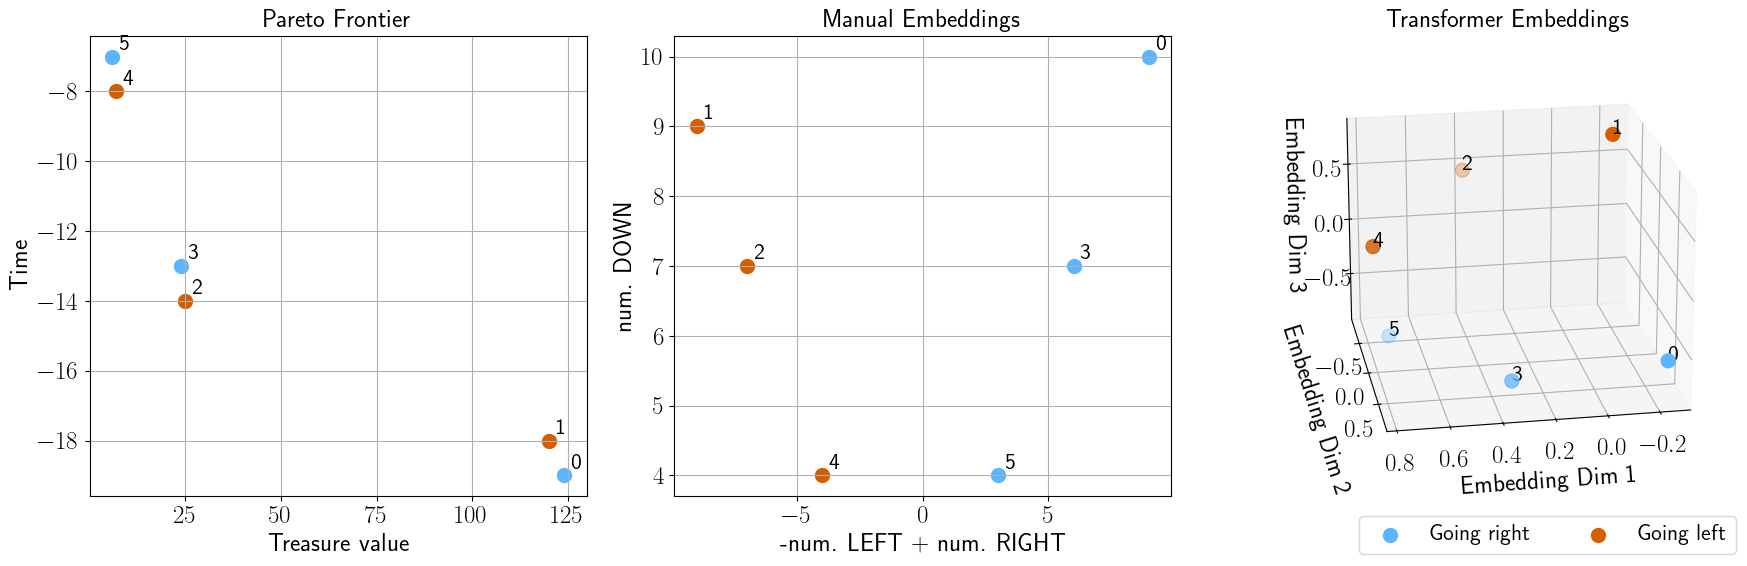

In [7]:
fig = plt.figure(figsize=(18, 6))

# fig.suptitle("Pareto Frontier and Embeddings in Left-Right DST", fontsize=20)

# Define point groups
left_indices = [1, 2, 4]  # Going left (orange)
right_indices = [i for i in range(len(sorted_pf_lr_gt)) if i not in left_indices]  # Going right (blue)

# 2D scatter for returns (use sorted version)
ax2 = fig.add_subplot(131)
ax2.scatter(sorted_pf_lr_gt[right_indices,0], sorted_pf_lr_gt[right_indices,1], 
            c=colors[0], marker="o", label="Going right", s=100)
ax2.scatter(sorted_pf_lr_gt[left_indices,0], sorted_pf_lr_gt[left_indices,1], 
            c=colors[1], marker="o", label="Going left", s=100)
ax2.set_title("Pareto Frontier")
ax2.set_xlabel("Treasure value")
ax2.grid(True)
ax2.set_ylabel("Time")
# Add numbered labels
for i in range(len(sorted_pf_lr_gt)):
    ax2.annotate(str(i), (sorted_pf_lr_gt[i,0], sorted_pf_lr_gt[i,1]), xytext=(5, 5), textcoords="offset points", fontsize=16)

# 2D scatter for ground truth embeddings (use sorted version)
ax3 = fig.add_subplot(132)
ax3.scatter(sorted_emb_lr_gt[right_indices,0], sorted_emb_lr_gt[right_indices,1], 
            c=colors[0], marker="o", label="Going right", s=100)
ax3.scatter(sorted_emb_lr_gt[left_indices,0], sorted_emb_lr_gt[left_indices,1], 
            c=colors[1], marker="o", label="Going left", s=100)
ax3.set_title("Manual Embeddings")
ax3.set_xlabel("-num. LEFT + num. RIGHT")
ax3.set_ylabel("num. DOWN")
ax3.grid(True)
# Add numbered labels
for i in range(len(sorted_emb_lr_gt)):
    ax3.annotate(str(i), (sorted_emb_lr_gt[i,0], sorted_emb_lr_gt[i,1]), xytext=(5, 5), textcoords="offset points", fontsize=16)

# 3D scatter for transformer embeddings (use sorted version)
ax1 = fig.add_subplot(133, projection="3d")
ax1.scatter(sorted_emb_lr_t[right_indices,0], sorted_emb_lr_t[right_indices,1], sorted_emb_lr_t[right_indices,2], 
            c=colors[0], marker="o", label="Going right", s=100)
ax1.scatter(sorted_emb_lr_t[left_indices,0], sorted_emb_lr_t[left_indices,1], sorted_emb_lr_t[left_indices,2], 
            c=colors[1], marker="o", label="Going left", s=100)
ax1.set_title("Transformer Embeddings")
ax1.set_xlabel("Embedding Dim 1", labelpad=10)
ax1.set_ylabel("Embedding Dim 2", labelpad=10)
ax1.set_zlabel("Embedding Dim 3", labelpad=10)
ax1.grid(True)
# change view
ax1.view_init(elev=20, azim=80)
# Add numbered labels
for i in range(len(sorted_emb_lr_t)):
    ax1.text(sorted_emb_lr_t[i,0], sorted_emb_lr_t[i,1], sorted_emb_lr_t[i,2], str(i), fontsize=16)

# Create a single legend for the entire figure
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.13), ncol=2)

plt.tight_layout()
plt.savefig("pareto_front_embeddings_left_right.pdf")
plt.show()

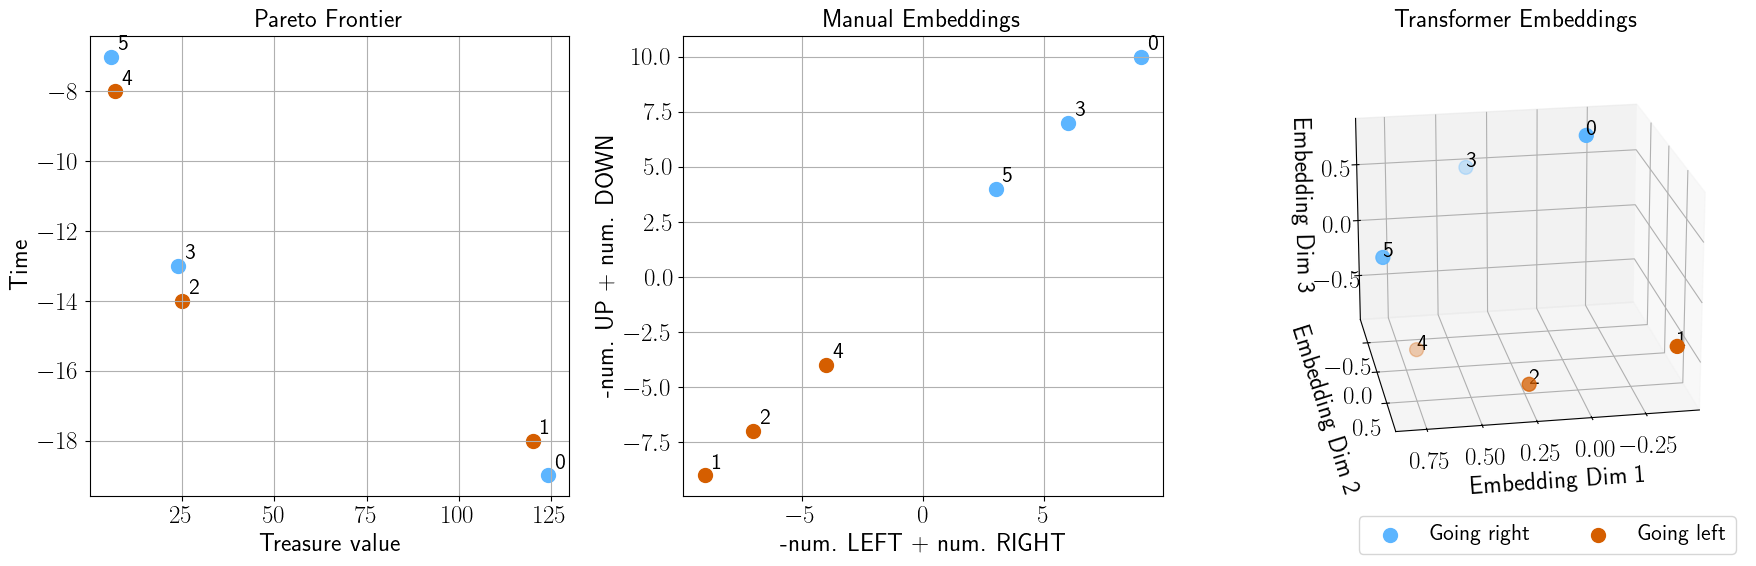

In [21]:
fig = plt.figure(figsize=(18, 6))

# fig.suptitle("Pareto Frontier and Embeddings in Louvre DST", fontsize=20)

# Define point groups
left_indices = [1, 2, 4]  # Going left (orange)
right_indices = [i for i in range(len(sorted_pf_lr_gt)) if i not in left_indices]  # Going right (blue)

# 2D scatter for returns (use sorted version)
ax2 = fig.add_subplot(131)
ax2.scatter(sorted_pf_louvre_gt[right_indices,0], sorted_pf_louvre_gt[right_indices,1], 
            c=colors[0], marker="o", label="Going right", s=100)
ax2.scatter(sorted_pf_louvre_gt[left_indices,0], sorted_pf_louvre_gt[left_indices,1], 
            c=colors[1], marker="o", label="Going left", s=100)
ax2.set_title("Pareto Frontier")
ax2.set_xlabel("Treasure value")
ax2.grid(True)
ax2.set_ylabel("Time")
# Add numbered labels
for i in range(len(sorted_pf_louvre_gt)):
    ax2.annotate(str(i), (sorted_pf_louvre_gt[i,0], sorted_pf_louvre_gt[i,1]), xytext=(5, 5), textcoords="offset points", fontsize=16)

# 2D scatter for ground truth embeddings (use sorted version)
ax3 = fig.add_subplot(132)
ax3.scatter(sorted_emb_louvre_gt[right_indices,0], sorted_emb_louvre_gt[right_indices,1], 
            c=colors[0], marker="o", label="Going right", s=100)
ax3.scatter(sorted_emb_louvre_gt[left_indices,0], sorted_emb_louvre_gt[left_indices,1], 
            c=colors[1], marker="o", label="Going left", s=100)
ax3.set_title("Manual Embeddings")
ax3.set_xlabel("-num. LEFT + num. RIGHT")
ax3.set_ylabel("-num. UP + num. DOWN")
ax3.grid(True)
# Add numbered labels
for i in range(len(sorted_emb_louvre_gt)):
    ax3.annotate(str(i), (sorted_emb_louvre_gt[i,0], sorted_emb_louvre_gt[i,1]), xytext=(5, 5), textcoords="offset points", fontsize=16)

# 3D scatter for transformer embeddings (use sorted version)
ax1 = fig.add_subplot(133, projection="3d")
ax1.scatter(sorted_emb_louvre_t[right_indices,0], sorted_emb_louvre_t[right_indices,1], sorted_emb_louvre_t[right_indices,2], 
            c=colors[0], marker="o", label="Going right", s=100)
ax1.scatter(sorted_emb_louvre_t[left_indices,0], sorted_emb_louvre_t[left_indices,1], sorted_emb_louvre_t[left_indices,2], 
            c=colors[1], marker="o", label="Going left", s=100)
ax1.set_title("Transformer Embeddings")
ax1.set_xlabel("Embedding Dim 1", labelpad=10)
ax1.set_ylabel("Embedding Dim 2", labelpad=10)
ax1.set_zlabel("Embedding Dim 3", labelpad=10)
ax1.grid(True)
# change view
ax1.view_init(elev=20, azim=80)
# Add numbered labels
for i in range(len(sorted_emb_louvre_t)):
    ax1.text(sorted_emb_louvre_t[i,0], sorted_emb_louvre_t[i,1], sorted_emb_louvre_t[i,2], str(i), fontsize=16)

# Create a single legend for the entire figure
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.13), ncol=2)

plt.tight_layout()
plt.savefig("pareto_front_embeddings_louvre.pdf")
plt.show()

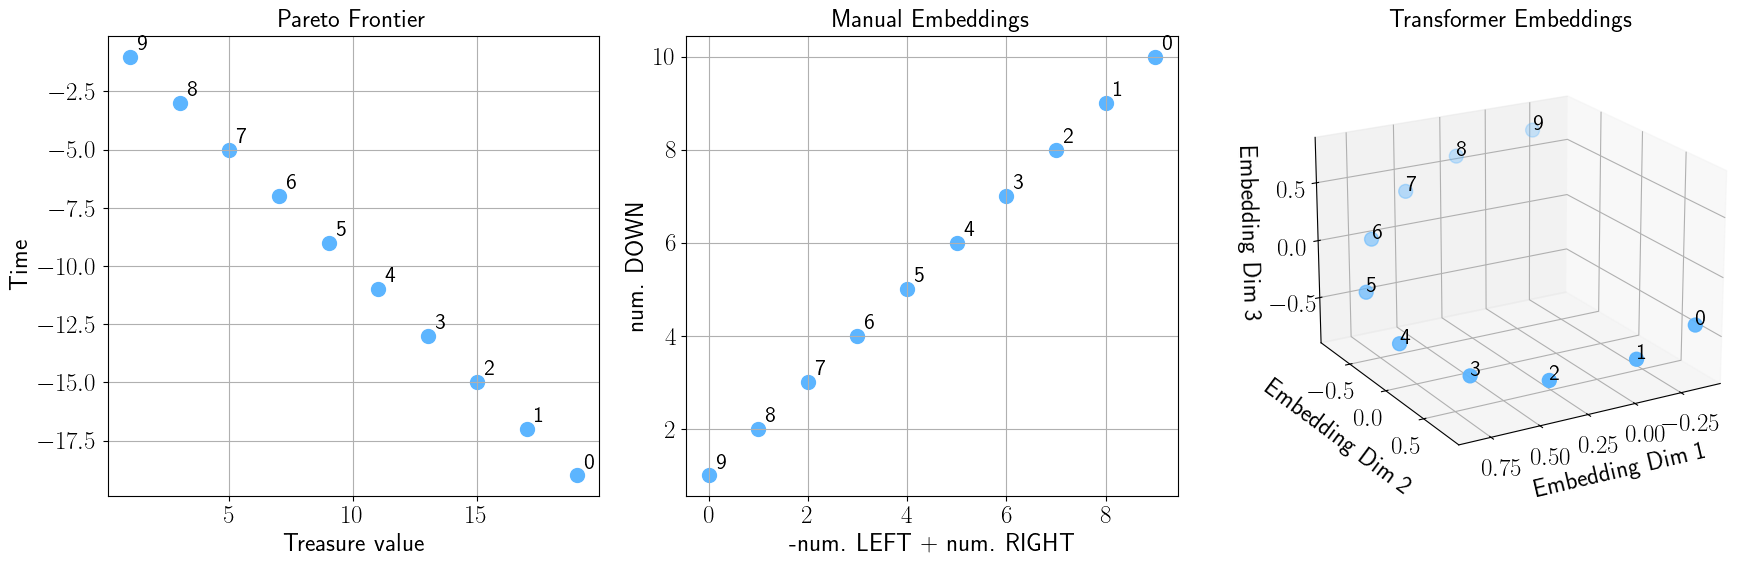

In [10]:
fig = plt.figure(figsize=(18, 6))

# fig.suptitle("Pareto Frontier and Embeddings in Smooth DST", fontsize=20)

# 2D scatter for returns (use sorted version)
ax2 = fig.add_subplot(131)
ax2.scatter(sorted_pf_smooth_gt[:,0], sorted_pf_smooth_gt[:,1], c=colors[0], marker="o", s=100)
ax2.set_title("Pareto Frontier")
ax2.set_xlabel("Treasure value")
ax2.grid(True)
ax2.set_ylabel("Time")
# Add numbered labels
for i in range(len(sorted_pf_smooth_gt)):
    ax2.annotate(str(i), (sorted_pf_smooth_gt[i,0], sorted_pf_smooth_gt[i,1]), xytext=(5, 5), textcoords="offset points", fontsize=16)

# 2D scatter for ground truth embeddings (use sorted version)
ax3 = fig.add_subplot(132)
ax3.scatter(sorted_emb_smooth_gt[:,0], sorted_emb_smooth_gt[:,1], 
            c=colors[0], marker="o", s=100)
ax3.set_title("Manual Embeddings")
ax3.set_xlabel("-num. LEFT + num. RIGHT")
ax3.set_ylabel("num. DOWN")
ax3.grid(True)
# Add numbered labels
for i in range(len(sorted_emb_smooth_gt)):
    ax3.annotate(str(i), (sorted_emb_smooth_gt[i,0], sorted_emb_smooth_gt[i,1]), xytext=(5, 5), textcoords="offset points", fontsize=16)

# 3D scatter for transformer embeddings (use sorted version)
ax1 = fig.add_subplot(133, projection="3d")
ax1.scatter(sorted_emb_smooth_t[:,0], sorted_emb_smooth_t[:,1], sorted_emb_smooth_t[:,2], 
            c=colors[0], marker="o", s=100)
ax1.set_title("Transformer Embeddings")
ax1.set_xlabel("Embedding Dim 1", labelpad=10)
ax1.set_ylabel("Embedding Dim 2", labelpad=10)
ax1.set_zlabel("Embedding Dim 3", labelpad=10)
ax1.grid(True)
# change view
ax1.view_init(elev=20, azim=60)
# Add numbered labels
for i in range(len(sorted_emb_smooth_t)):
    ax1.text(sorted_emb_smooth_t[i,0], sorted_emb_smooth_t[i,1], sorted_emb_smooth_t[i,2], str(i), fontsize=16)

plt.tight_layout()
plt.savefig("pareto_front_embeddings_smooth.pdf")
plt.show()

## Average Scatterplots

In [14]:
from morl_behavior_objective.analysis.utils_analysis import compute_lipschitz_constants

emb_dst_lr = []
emb_dst_smooth = []
for seed in range(5):
    # Configuration for datasets
    environments = {
        "left_right": {
            "trajectory_dir": "../../trajectories/left_right_dst/seed0",
            "embedding_path": f"../../trajectories/left_right_dst/embeddings/mean_be_DSTLR_e100_seed{seed}.json",
        },
        "smooth": {
            "trajectory_dir": f"../../trajectories/smooth/seed0",
            "embedding_path": f"../../trajectories/smooth/embeddings/mean_be_DSTS_e100_seed{seed}.json",
        },
    }
    print(environments["left_right"])
    all_t_emb_lr, _=load_transformer_embeddings(environments["left_right"]["embedding_path"])
    all_t_emb_smooth, _=load_transformer_embeddings(environments["smooth"]["embedding_path"])

    _, d_objs_lr, d_embs_lr, sorted_pf_lr, sorted_emb_lr = (
    compute_lipschitz_constants(pareto_frontier=all_returns_lr, embeddings=all_t_emb_lr)    
)
   
    lipschitz_constants_smooth, d_objs_smooth, d_embs_smooth, sorted_pf_smooth, sorted_emb_smooth = (
    compute_lipschitz_constants(pareto_frontier=all_returns_smooth, embeddings=all_t_emb_smooth)
)   

    emb_dst_lr.append(d_embs_lr)
    emb_dst_smooth.append(d_embs_smooth)

emb_dst_lr=np.array(emb_dst_lr)
emb_dst_smooth=np.array(emb_dst_smooth)

#compute mean of seeds for emb_dst_cheetah and emb_dst_hopper_3d
emb_dst_lr_mean=np.mean(emb_dst_lr,axis=0)
emb_dst_smooth_mean=np.mean(emb_dst_smooth,axis=0)
print(emb_dst_lr_mean.shape)
print(emb_dst_smooth_mean.shape)

{'trajectory_dir': '../../trajectories/left_right_dst/seed0', 'embedding_path': '../../trajectories/left_right_dst/embeddings/mean_be_DSTLR_e100_seed0.json'}
Computing Lipschitz constant between policy 0 and 1
4.123105625617661
1.921733433299718
Lipshitz: 0.4660888193985652
Lipschitz constant for policy 0 ([124. -19.], [-0.24489307  0.79421502 -0.55610257]) to 1 ([120. -18.], [-0.20719148 -0.57615286  0.7906453 ]): 0.4660888193985652, d_obj: 4.123105625617661, d_emb: 1.921733433299718
Computing Lipschitz constant between policy 1 and 2
95.08417323613851
0.7233245122125095
Lipshitz: 0.007607201993713045
Lipschitz constant for policy 1 ([120. -18.], [-0.20719148 -0.57615286  0.7906453 ]) to 2 ([ 25. -14.], [ 0.38026553 -0.81283158  0.44125184]): 0.007607201993713045, d_obj: 95.08417323613851, d_emb: 0.7233245122125095
Computing Lipschitz constant between policy 2 and 3
1.4142135623730951
1.8067992342855792
Lipshitz: 1.2775999908059945
Lipschitz constant for policy 2 ([ 25. -14.], [ 0.380

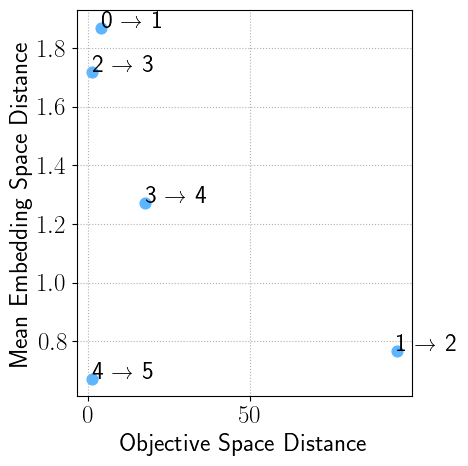

In [16]:
plt.figure(figsize=(5, 5))

plt.scatter(
    d_objs_lr,
    emb_dst_lr_mean,
    c=colors[0],
    s=60
)

plt.xlabel("Objective Space Distance")
plt.ylabel("Mean Embedding Space Distance")

plt.grid(True, linestyle=":")

for i in range(len(d_objs_lr)):
    plt.annotate(
        f"{i} → {i + 1}",
            (d_objs_lr[i], emb_dst_lr_mean[i])
    )

plt.tight_layout()
plt.savefig(
    f"left_right_d_mean.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()


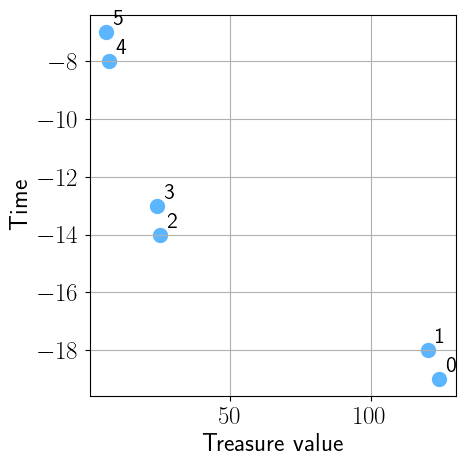

In [30]:
plt.figure(figsize=(5, 5))
plt.scatter(sorted_pf_lr_gt[:,0], sorted_pf_lr_gt[:,1], c=colors[0], marker="o", s=100)
#plt.title("Pareto Frontier")
plt.xlabel("Treasure value")
plt.grid(True)
plt.ylabel("Time")
# Add numbered labels
for i in range(len(sorted_pf_lr_gt)):
    plt.annotate(str(i), (sorted_pf_lr_gt[i,0], sorted_pf_lr_gt[i,1]), xytext=(5, 5), textcoords="offset points", fontsize=16)

plt.tight_layout()
plt.savefig(
    f"left_right_pf.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

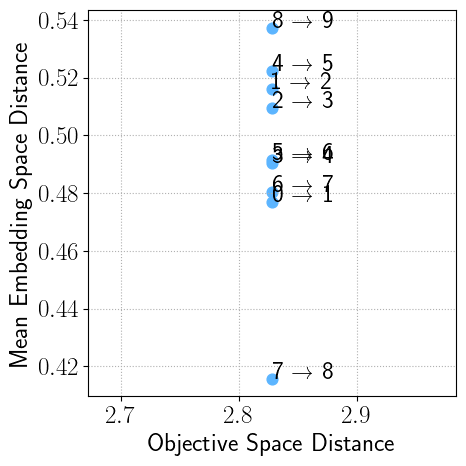

In [22]:
plt.figure(figsize=(5, 5))

plt.scatter(
    d_objs_smooth,
    emb_dst_smooth_mean,
    c=colors[0],
    s=60
)

plt.xlabel("Objective Space Distance")
plt.ylabel("Mean Embedding Space Distance")

plt.grid(True, linestyle=":")

for i in range(len(d_objs_smooth)):
    plt.annotate(
        f"{i} → {i + 1}",
            (d_objs_smooth[i], emb_dst_smooth_mean[i])
    )

plt.tight_layout()
plt.savefig(
    f"smooth_d_mean.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()


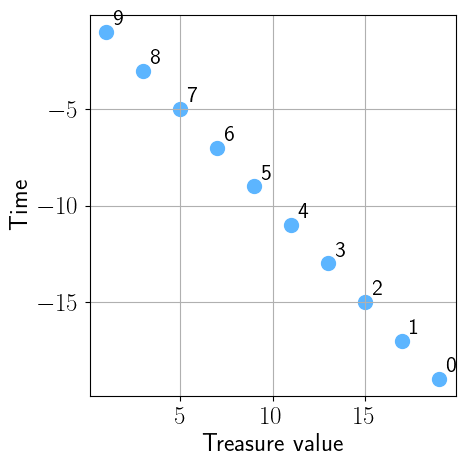

In [31]:
plt.figure(figsize=(5, 5))
plt.scatter(sorted_pf_smooth_gt[:,0], sorted_pf_smooth_gt[:,1], c=colors[0], marker="o", s=100)
#plt.title("Pareto Frontier")
plt.xlabel("Treasure value")
plt.grid(True)
plt.ylabel("Time")
# Add numbered labels
for i in range(len(sorted_pf_smooth_gt)):
    plt.annotate(str(i), (sorted_pf_smooth_gt[i,0], sorted_pf_smooth_gt[i,1]), xytext=(5, 5), textcoords="offset points", fontsize=16)

plt.tight_layout()
plt.savefig(
    f"smooth_pf.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()